In [132]:
%load_ext autoreload
%autoreload 2
from DSA_env import DSA_Markov
from DQN_RC import DeepQNetwork
from OnlineActorCritic import OnlineActorCritic
from OnlineActorCriticSNN import OnlineActorCriticSNN
from OnlineActorCriticSNNPop import OnlineActorCriticSNNPop

import matplotlib.pyplot as plt
import numpy as np
import copy
import os


def plot_metric(metric_list, labels, title, ylabel, batch_size):
    plt.figure(figsize=(10, 6))

    for data, label in zip(metric_list, labels):
        if data is not None and len(data) > 0:
            x = np.arange(1, len(data) + 1) * batch_size
            plt.plot(x, data, label=label)

    plt.xlabel('Training Step')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [133]:
import numpy as np
import matplotlib.pyplot as plt
import copy

# -------------------------
# Config
# -------------------------
n_steps = 5000

env_diag = copy.deepcopy(env_copy)


no_tx_action = [env_diag.n_channel,env_diag.n_channel]
action = np.full(n_su, no_tx_action, dtype=np.int32)

# -------------------------
# Detect optional variables
# -------------------------
has_pu_state = hasattr(env_diag, "PU_state")
has_pu_interf = hasattr(env_diag, "Interferecne_PU")

# -------------------------
# Logs for SU0
# -------------------------
obs_log = np.zeros((n_steps, n_channel))
sinr_log = np.zeros((n_steps, n_channel))

if has_pu_state:
    pu_state_log = np.zeros((n_steps, n_channel))

if has_pu_interf:
    pu_interf_log = np.zeros((n_steps, n_channel))

# -------------------------
# Run environment
# -------------------------
observation = env_diag.sense()

for t in range(n_steps):
    obs_log[t, :] = observation[0, :]
    sinr_log[t, :] = env_diag.SINR[0, :]

    if has_pu_state:
        pu_state_log[t, :] = env_diag.PU_state

    if has_pu_interf:
        pu_interf_log[t, :] = env_diag.Interferecne_PU[0, :]

    env_diag.render()
    env_diag.render_SINR()
    _ = env_diag.access(action)

    observation = env_diag.sense()

print("Logging complete.")
print("obs_log shape:", obs_log.shape)
print("sinr_log shape:", sinr_log.shape)
if has_pu_state:
    print("pu_state_log shape:", pu_state_log.shape)
if has_pu_interf:
    print("pu_interf_log shape:", pu_interf_log.shape)


pu_true_log = np.zeros((n_steps, n_channel))
obs_log = np.zeros((n_steps, n_channel))

observation = env.sense()

for t in range(n_steps):
    obs_log[t] = observation[0]              # noisy observation
    pu_true_log[t] = env.get_true_PU_state() # true state

    env.access(no_tx_action)
    observation = env.sense()


Logging complete.
obs_log shape: (5000, 6)
sinr_log shape: (5000, 6)
pu_interf_log shape: (5000, 6)


In [134]:
def scatter_grid(x_log, y_log, x_label, y_label, title_prefix, n_channel):
    cols = 3
    rows = int(np.ceil(n_channel / cols))
    plt.figure(figsize=(5 * cols, 4 * rows))

    for ch in range(n_channel):
        ax = plt.subplot(rows, cols, ch + 1)
        ax.scatter(x_log[:, ch], y_log[:, ch], s=6, alpha=0.5)
        ax.set_title(f"{title_prefix} - Channel {ch}")
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
        ax.grid(True)

    plt.tight_layout()
    plt.show()


def hist_grid(data_log, x_label, title_prefix, n_channel, bins=40):
    cols = 3
    rows = int(np.ceil(n_channel / cols))
    plt.figure(figsize=(5 * cols, 4 * rows))

    for ch in range(n_channel):
        ax = plt.subplot(rows, cols, ch + 1)
        ax.hist(data_log[:, ch], bins=bins, alpha=0.8)
        ax.set_title(f"{title_prefix} - Channel {ch}")
        ax.set_xlabel(x_label)
        ax.set_ylabel("Count")
        ax.grid(True)

    plt.tight_layout()
    plt.show()



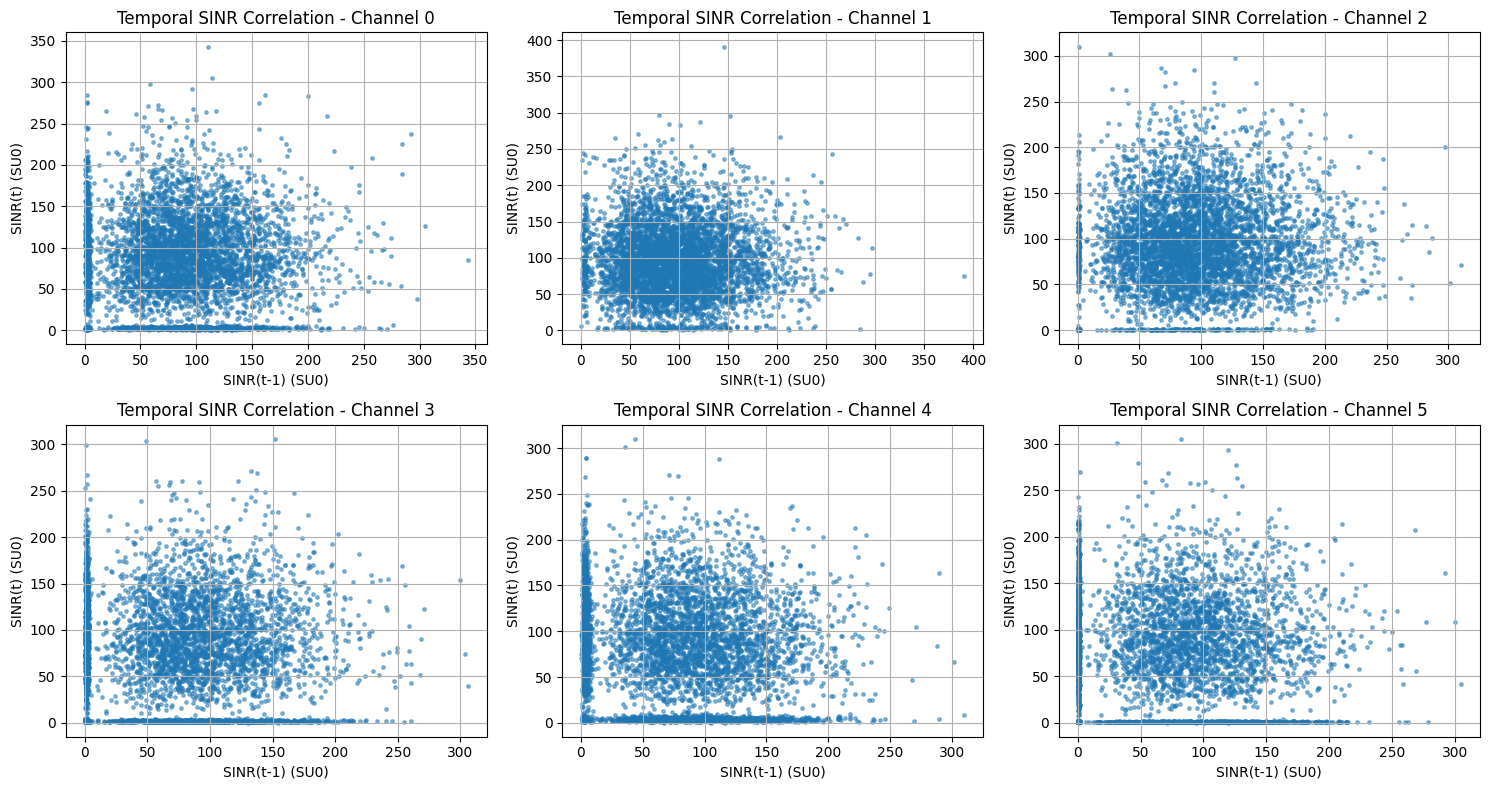

In [135]:
sinr_prev = sinr_log[:-1, :]
sinr_curr = sinr_log[1:, :]

scatter_grid(
    x_log=sinr_prev,
    y_log=sinr_curr,
    x_label="SINR(t-1) (SU0)",
    y_label="SINR(t) (SU0)",
    title_prefix="Temporal SINR Correlation",
    n_channel=n_channel
)


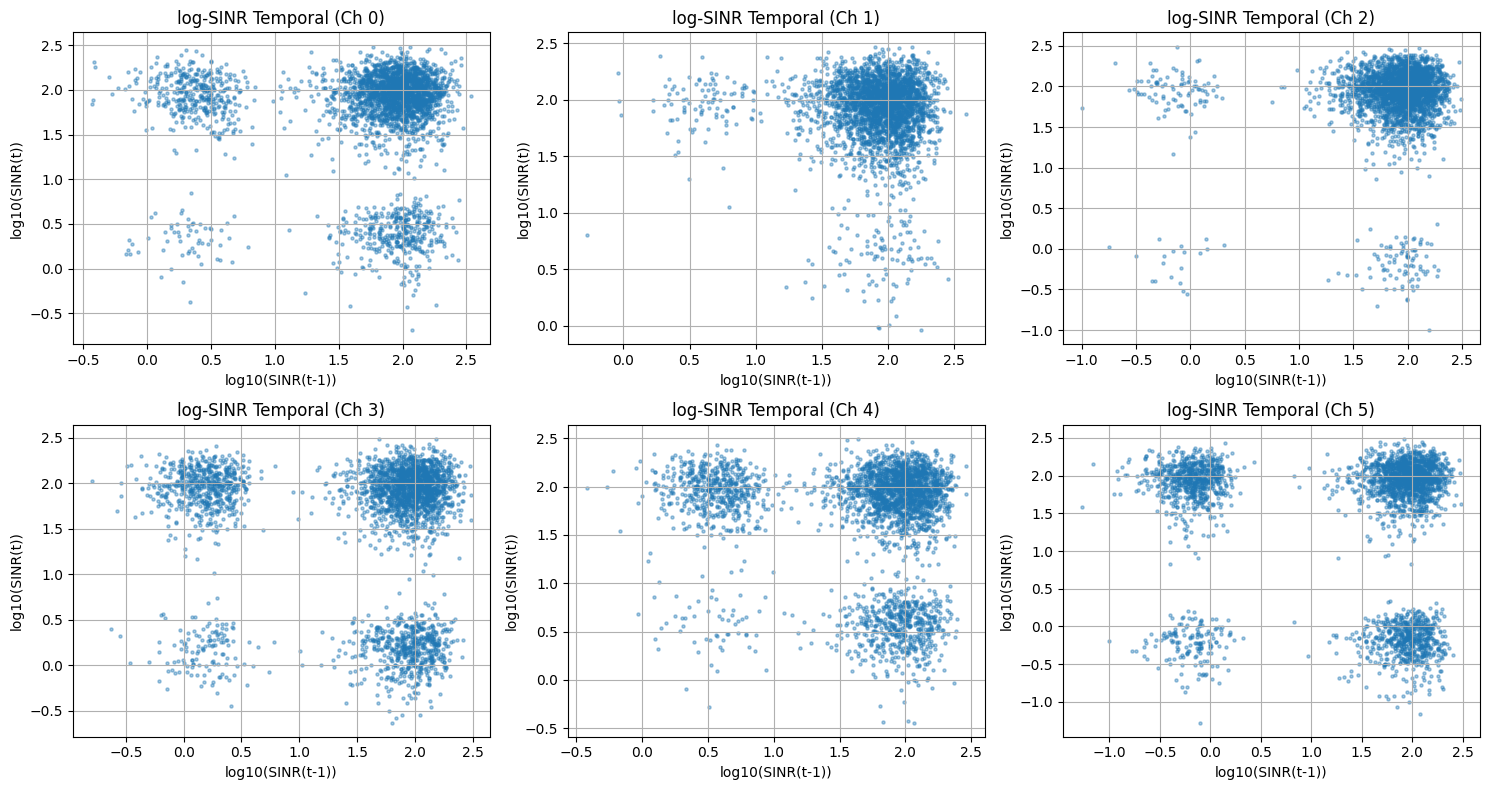

In [136]:
import numpy as np
import matplotlib.pyplot as plt

eps = 1e-12  # avoid log(0)

# safe log transform
sinr_safe = np.maximum(sinr_log, eps)
log_sinr = np.log10(sinr_safe)

# temporal pairs
log_prev = log_sinr[:-1, :]
log_curr = log_sinr[1:, :]

def temporal_log_scatter(log_prev, log_curr, n_channel, sample=3000):
    cols = 3
    rows = int(np.ceil(n_channel / cols))
    plt.figure(figsize=(5 * cols, 4 * rows))

    for ch in range(n_channel):
        ax = plt.subplot(rows, cols, ch + 1)

        x = log_prev[:, ch]
        y = log_curr[:, ch]

        # optional subsample for readability
        if len(x) > sample:
            idx = np.random.choice(len(x), sample, replace=False)
            x = x[idx]
            y = y[idx]

        ax.scatter(x, y, s=5, alpha=0.4)


        ax.set_title(f"log-SINR Temporal (Ch {ch})")
        ax.set_xlabel("log10(SINR(t-1))")
        ax.set_ylabel("log10(SINR(t))")
        ax.grid(True)

    plt.tight_layout()
    plt.show()


# ---- Run plots ----
temporal_log_scatter(log_prev, log_curr, n_channel)


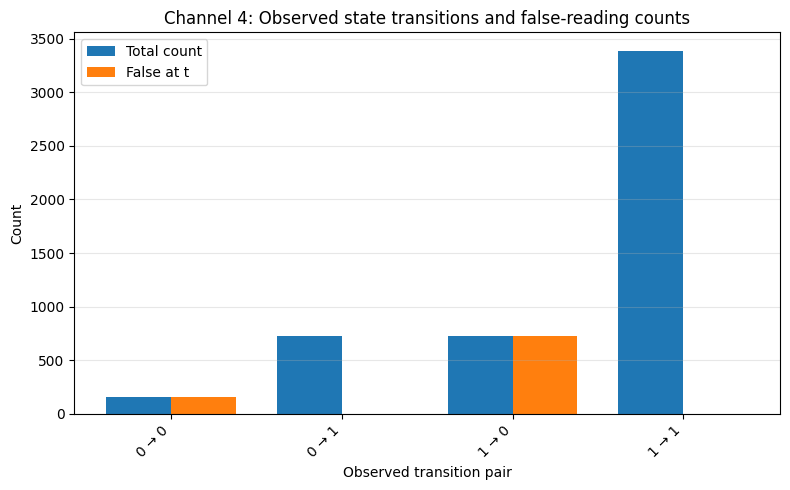

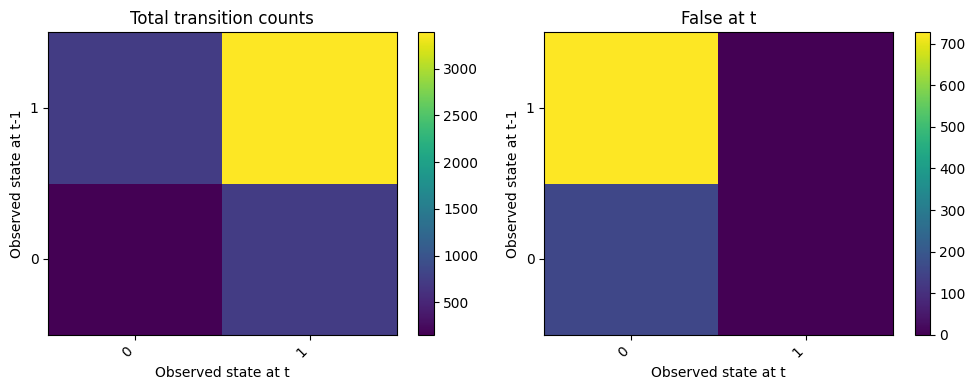

In [137]:
import numpy as np
import matplotlib.pyplot as plt

def plot_observation_transition_counts(
    obs_log,
    pu_true_log,
    channel=0,
    bins=None,
    use_any_false=False
):
    """
    Plot counts of temporal observation pairs for one channel.

    Parameters
    ----------
    obs_log : array, shape (T, n_channel)
        Observed/sensed state.
    pu_true_log : array, shape (T, n_channel)
        True PU state.
    channel : int
        Channel index to analyze.
    bins : array-like or None
        If obs is continuous, provide bins. If None, tries to infer binary/discrete.
    use_any_false : bool
        If False: false count means observation at time t is incorrect.
        If True: false count means either t-1 or t is incorrect.
    """
    obs = np.asarray(obs_log[:, channel])
    true = np.asarray(pu_true_log[:, channel])

    # Decide whether data is effectively binary/discrete
    unique_vals = np.unique(obs)
    is_small_discrete = len(unique_vals) <= 10 and np.all(np.isclose(unique_vals, np.round(unique_vals)))

    if bins is None and is_small_discrete:
        # Use exact discrete values
        obs_disc = obs.astype(int)
        categories = np.sort(np.unique(obs_disc))
        cat_to_idx = {c: i for i, c in enumerate(categories)}
        obs_idx = np.array([cat_to_idx[v] for v in obs_disc])
        labels = [str(c) for c in categories]
    else:
        # Bin continuous values
        if bins is None:
            bins = np.linspace(np.min(obs), np.max(obs), 5)
        obs_idx = np.digitize(obs, bins[1:-1], right=False)
        n_bins = len(bins) - 1
        labels = [f"[{bins[i]:.2f},{bins[i+1]:.2f})" for i in range(n_bins)]

    prev_idx = obs_idx[:-1]
    curr_idx = obs_idx[1:]

    true_prev = true[:-1]
    true_curr = true[1:]
    obs_prev = obs[:-1]
    obs_curr = obs[1:]

    if use_any_false:
        false_mask = (obs_prev != true_prev) | (obs_curr != true_curr)
        false_title = "False at t-1 or t"
    else:
        false_mask = (obs_curr != true_curr)
        false_title = "False at t"

    n_cat = len(labels)
    total_counts = np.zeros((n_cat, n_cat), dtype=int)
    false_counts = np.zeros((n_cat, n_cat), dtype=int)

    for i in range(len(prev_idx)):
        a = prev_idx[i]
        b = curr_idx[i]
        total_counts[a, b] += 1
        if false_mask[i]:
            false_counts[a, b] += 1

    # Flatten for grouped bar chart
    pair_names = []
    total_vals = []
    false_vals = []

    for a in range(n_cat):
        for b in range(n_cat):
            pair_names.append(f"{labels[a]} → {labels[b]}")
            total_vals.append(total_counts[a, b])
            false_vals.append(false_counts[a, b])

    x = np.arange(len(pair_names))
    width = 0.38

    plt.figure(figsize=(max(8, 1.2 * len(pair_names)), 5))
    plt.bar(x - width/2, total_vals, width=width, label="Total count")
    plt.bar(x + width/2, false_vals, width=width, label=false_title)

    plt.xticks(x, pair_names, rotation=45, ha='right')
    plt.xlabel("Observed transition pair")
    plt.ylabel("Count")
    plt.title(f"Channel {channel}: Observed state transitions and false-reading counts")
    plt.legend()
    plt.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Optional heatmaps if you want cleaner structure
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    im0 = axes[0].imshow(total_counts, origin='lower', aspect='auto')
    axes[0].set_title("Total transition counts")
    axes[0].set_xlabel("Observed state at t")
    axes[0].set_ylabel("Observed state at t-1")
    axes[0].set_xticks(np.arange(n_cat))
    axes[0].set_yticks(np.arange(n_cat))
    axes[0].set_xticklabels(labels, rotation=45, ha='right')
    axes[0].set_yticklabels(labels)
    plt.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(false_counts, origin='lower', aspect='auto')
    axes[1].set_title(false_title)
    axes[1].set_xlabel("Observed state at t")
    axes[1].set_ylabel("Observed state at t-1")
    axes[1].set_xticks(np.arange(n_cat))
    axes[1].set_yticks(np.arange(n_cat))
    axes[1].set_xticklabels(labels, rotation=45, ha='right')
    axes[1].set_yticklabels(labels)
    plt.colorbar(im1, ax=axes[1])

    plt.tight_layout()
    plt.show()
plot_observation_transition_counts(
    obs_log=obs_log,
    pu_true_log=pu_true_log,
    channel=4,
    bins=None,
    use_any_false=False
)

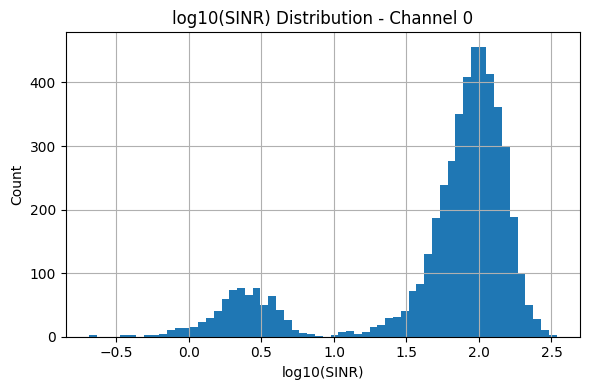

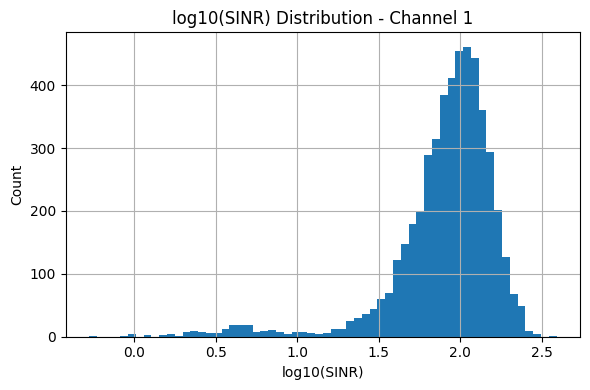

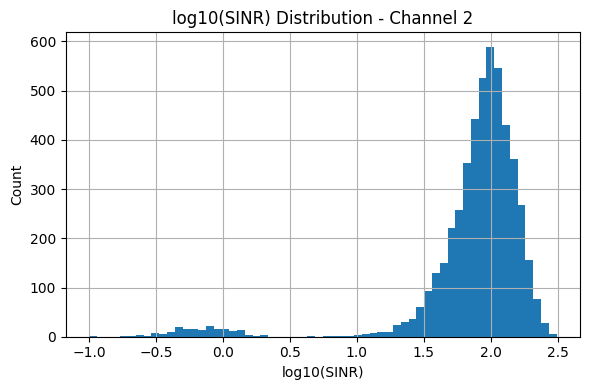

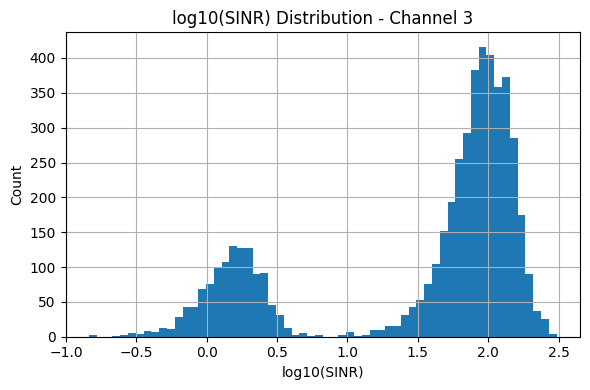

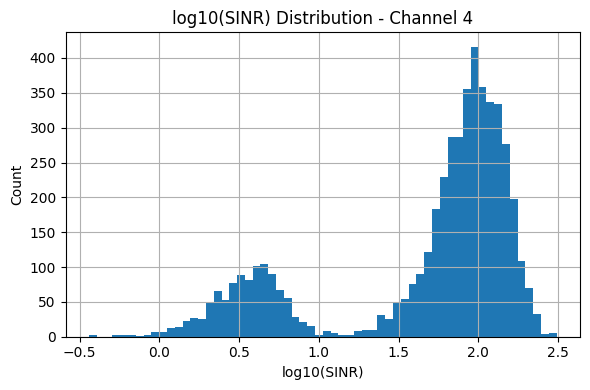

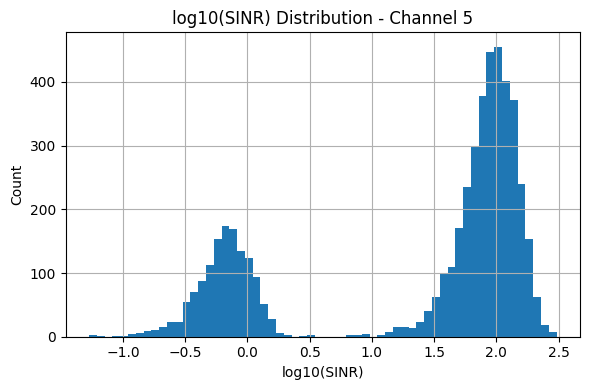

In [138]:
eps = 1e-8
sinr_log_safe = np.maximum(sinr_log, eps)

for ch in range(n_channel):
    plt.figure(figsize=(6,4))
    plt.hist(np.log10(sinr_log_safe[:, ch]), bins=60)
    plt.title(f"log10(SINR) Distribution - Channel {ch}")
    plt.xlabel("log10(SINR)")
    plt.ylabel("Count")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

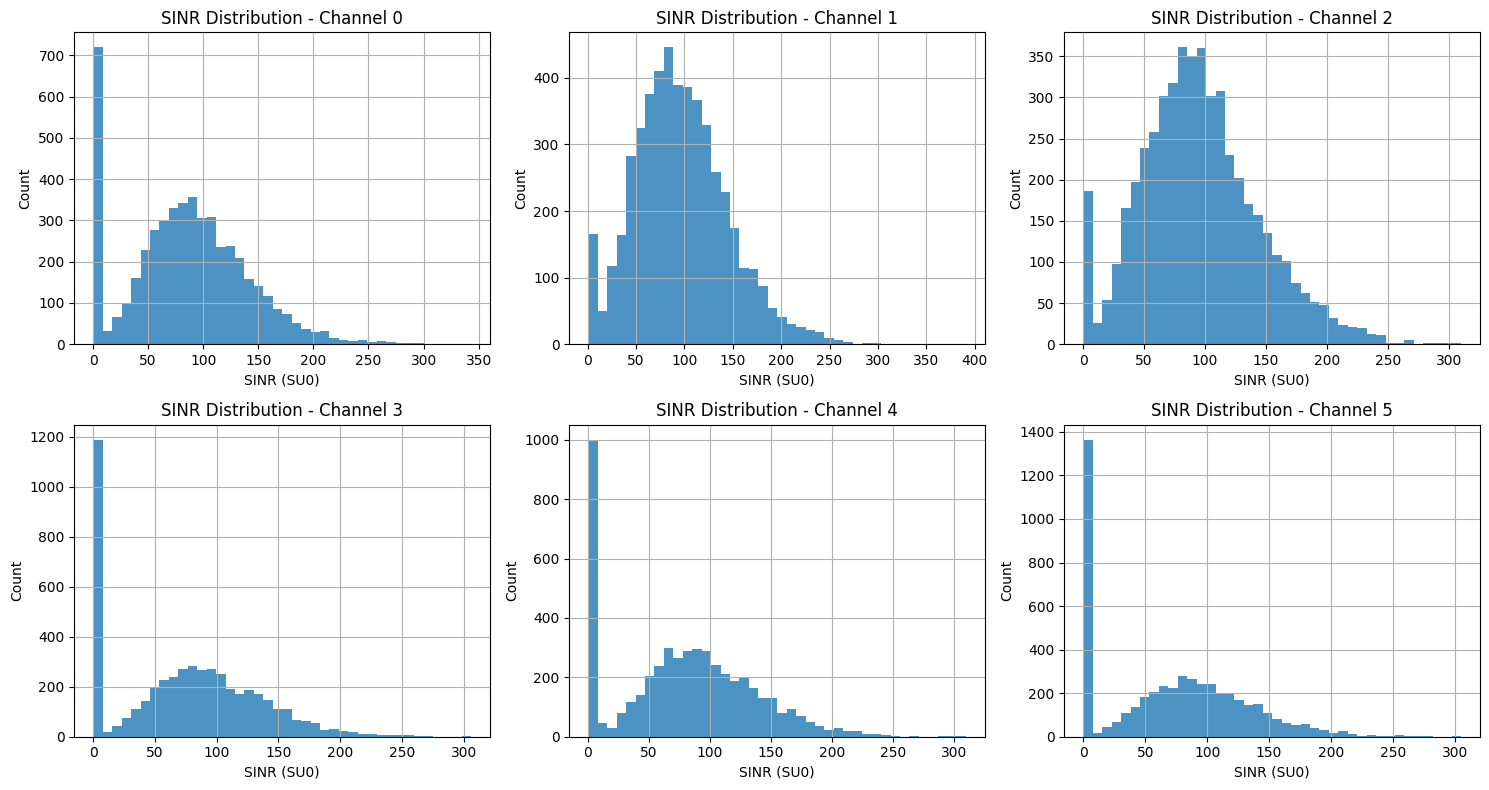

Global min SINR: 0.053349713264294524
Global max SINR: 391.20370500980573
Fraction exactly zero: 0.0
Fraction < 10: 0.15543333333333334


In [139]:
hist_grid(
    data_log=sinr_log,
    x_label="SINR (SU0)",
    title_prefix="SINR Distribution",
    n_channel=n_channel,
    bins=40
)
print("Global min SINR:", np.min(sinr_log))
print("Global max SINR:", np.max(sinr_log))
print("Fraction exactly zero:", np.mean(sinr_log == 0))
print("Fraction < 10:", np.mean(sinr_log < 10))

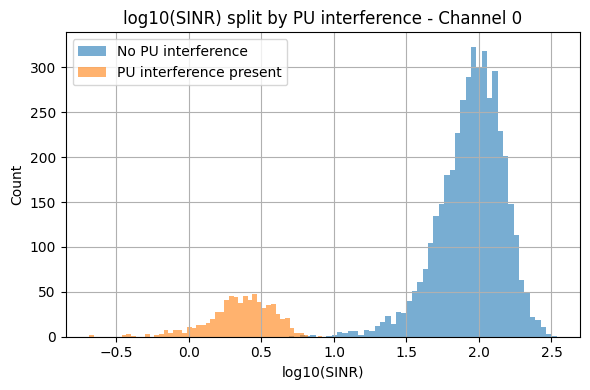

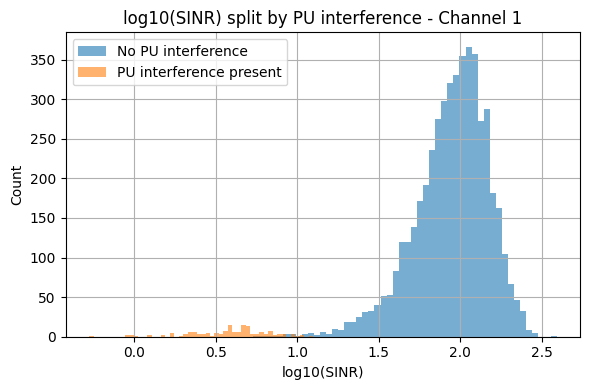

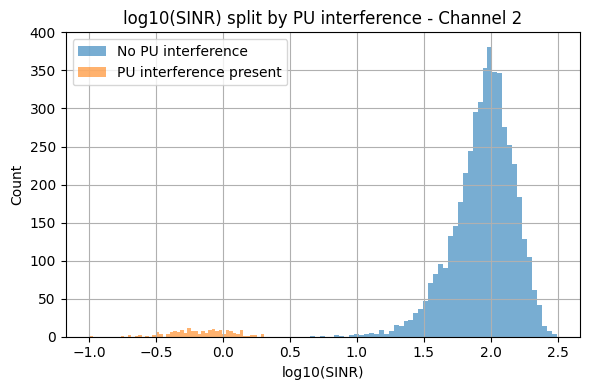

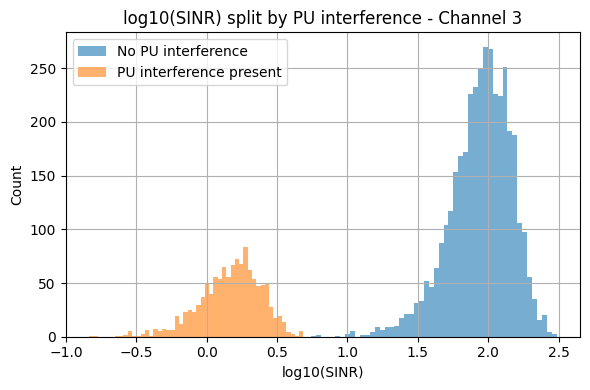

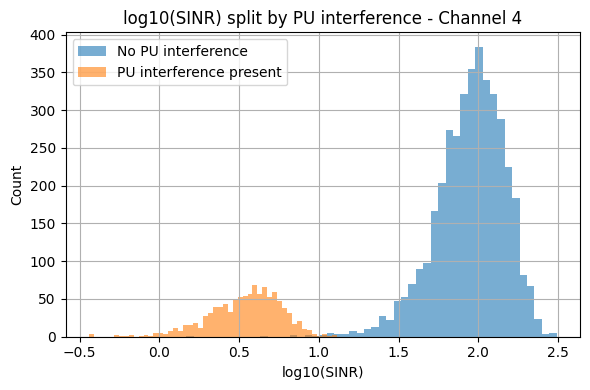

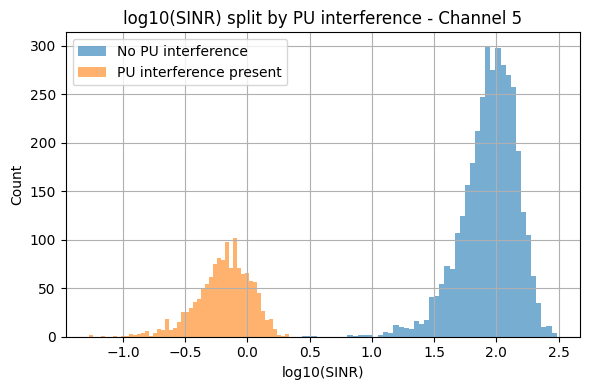

In [140]:
eps = 1e-12

for ch in range(n_channel):
    sinr_ch = np.maximum(sinr_log[:, ch], eps)
    pu_mask = pu_interf_log[:, ch] > 1e-12
    no_pu_mask = ~pu_mask

    plt.figure(figsize=(6,4))
    plt.hist(np.log10(sinr_ch[no_pu_mask]), bins=50, alpha=0.6, label='No PU interference')
    plt.hist(np.log10(sinr_ch[pu_mask]), bins=50, alpha=0.6, label='PU interference present')
    plt.title(f'log10(SINR) split by PU interference - Channel {ch}')
    plt.xlabel('log10(SINR)')
    plt.ylabel('Count')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [141]:
import numpy as np
import matplotlib.pyplot as plt
import copy

# -------------------------
# Config
# -------------------------
n_steps = 5000
su_idx = 0

env_in = copy.deepcopy(env_copy)

# no transmit action
action = np.full(n_su, env_in.n_channel, dtype=np.int32)

# raw model input log: each row is one input vector to the model
# shape: (n_steps, n_channel)
obs_log = np.zeros((n_steps, n_channel))

# optional proxy logs for coloring/splitting later
sinr_log = np.zeros((n_steps, n_channel))
if hasattr(env_in, "Interferecne_PU"):
    pu_interf_log = np.zeros((n_steps, n_channel))

observation = env_in.sense()

for t in range(n_steps):
    obs_log[t, :] = observation[su_idx, :]
    sinr_log[t, :] = env_in.SINR[su_idx, :]

    if hasattr(env_in, "Interferecne_PU"):
        pu_interf_log[t, :] = env_in.Interferecne_PU[su_idx, :]

    env_in.render()
    env_in.render_SINR()
    _ = env_in.access(action)

    observation = env_in.sense()

print("obs_log shape:", obs_log.shape)

obs_log shape: (5000, 6)


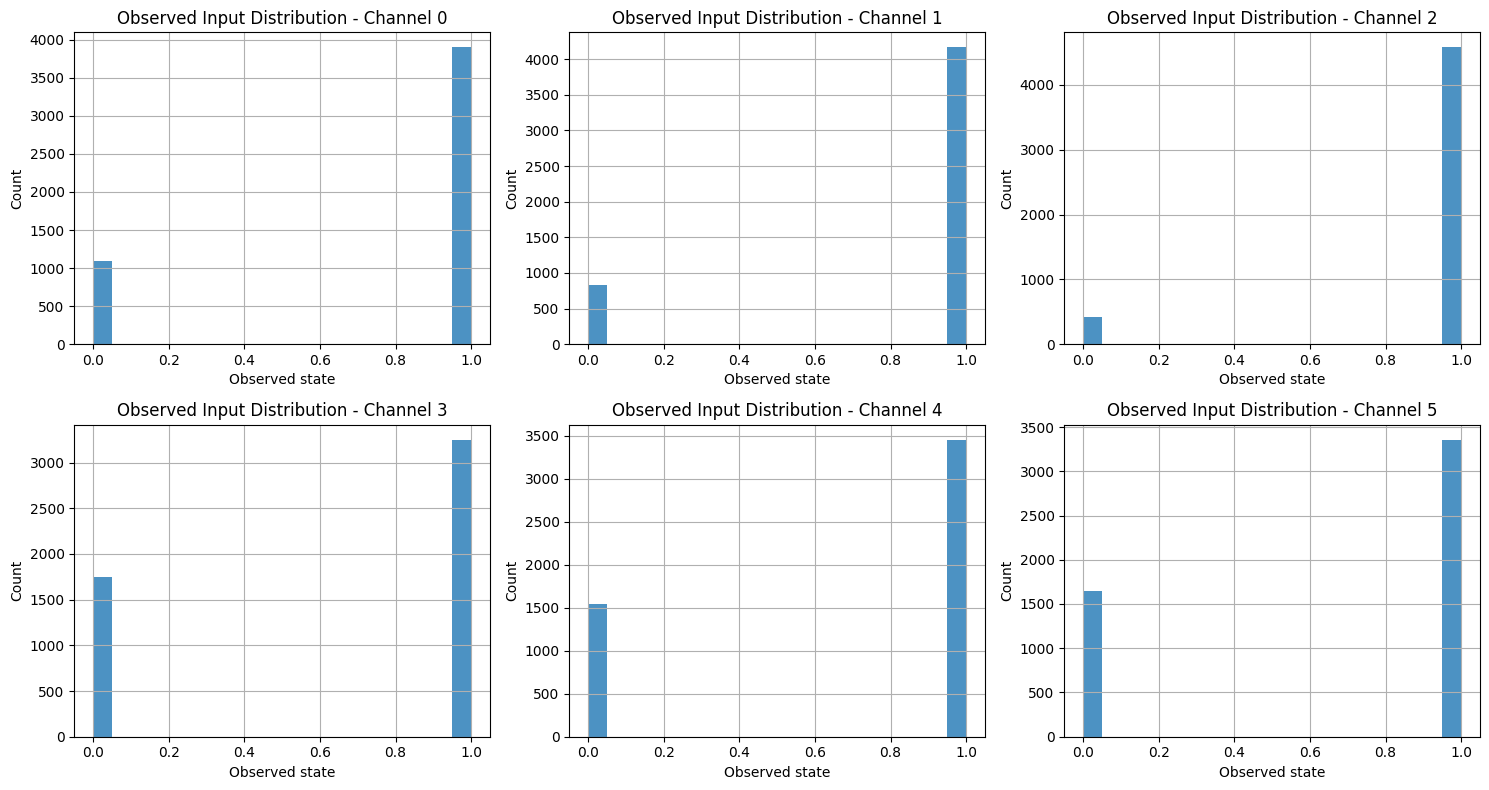

In [142]:
cols = 3
rows = int(np.ceil(n_channel / cols))

plt.figure(figsize=(5 * cols, 4 * rows))

for ch in range(n_channel):
    ax = plt.subplot(rows, cols, ch + 1)
    ax.hist(obs_log[:, ch], bins=20, alpha=0.8)
    ax.set_title(f"Observed Input Distribution - Channel {ch}")
    ax.set_xlabel("Observed state")
    ax.set_ylabel("Count")
    ax.grid(True)

plt.tight_layout()
plt.show()

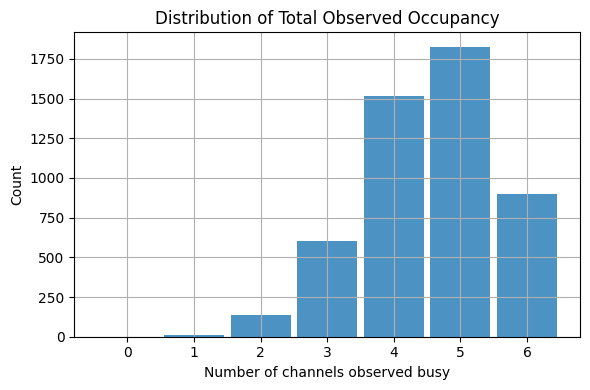

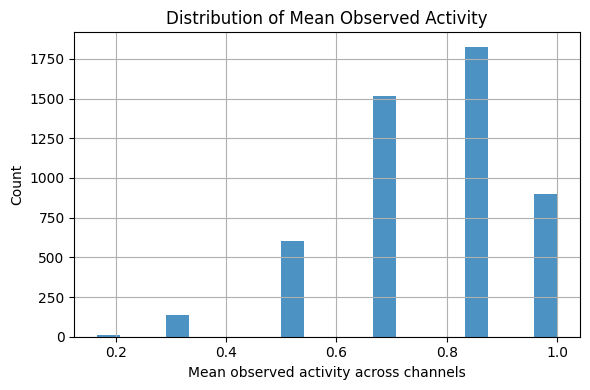

In [143]:
obs_sum = np.sum(obs_log, axis=1)
obs_mean = np.mean(obs_log, axis=1)

plt.figure(figsize=(6,4))
plt.hist(obs_sum, bins=np.arange(-0.5, n_channel + 1.5, 1), alpha=0.8, rwidth=0.9)
plt.xlabel("Number of channels observed busy")
plt.ylabel("Count")
plt.title("Distribution of Total Observed Occupancy")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.hist(obs_mean, bins=20, alpha=0.8)
plt.xlabel("Mean observed activity across channels")
plt.ylabel("Count")
plt.title("Distribution of Mean Observed Activity")
plt.grid(True)
plt.tight_layout()
plt.show()

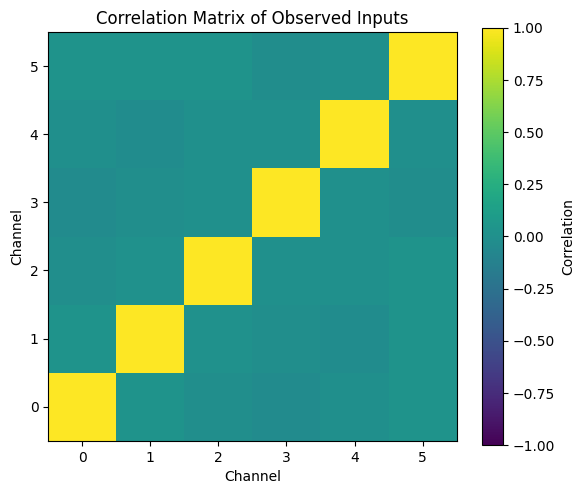

In [144]:
corr = np.corrcoef(obs_log, rowvar=False)

plt.figure(figsize=(6,5))
plt.imshow(corr, vmin=-1, vmax=1, origin='lower')
plt.colorbar(label='Correlation')
plt.xlabel("Channel")
plt.ylabel("Channel")
plt.title("Correlation Matrix of Observed Inputs")
plt.tight_layout()
plt.show()

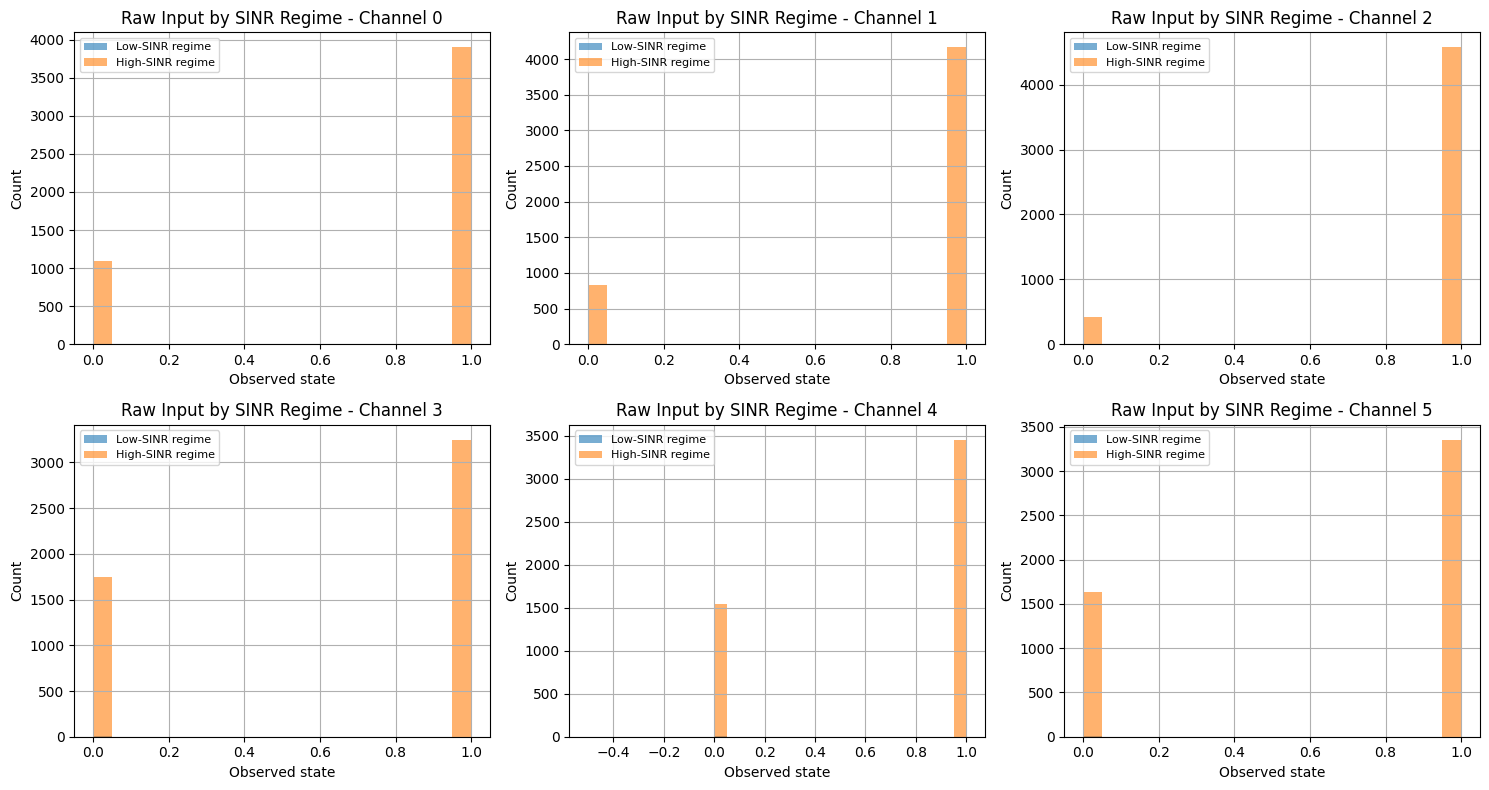

In [145]:
avg_log_sinr = np.mean(np.log10(np.maximum(sinr_log, 1e-12)), axis=1)

# choose a threshold between your two modes
sinr_thresh = 0.75

low_mask = avg_log_sinr < sinr_thresh
high_mask = avg_log_sinr >= sinr_thresh

cols = 3
rows = int(np.ceil(n_channel / cols))

plt.figure(figsize=(5 * cols, 4 * rows))

for ch in range(n_channel):
    ax = plt.subplot(rows, cols, ch + 1)
    ax.hist(obs_log[low_mask, ch], bins=20, alpha=0.6, label='Low-SINR regime')
    ax.hist(obs_log[high_mask, ch], bins=20, alpha=0.6, label='High-SINR regime')
    ax.set_title(f"Raw Input by SINR Regime - Channel {ch}")
    ax.set_xlabel("Observed state")
    ax.set_ylabel("Count")
    ax.grid(True)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

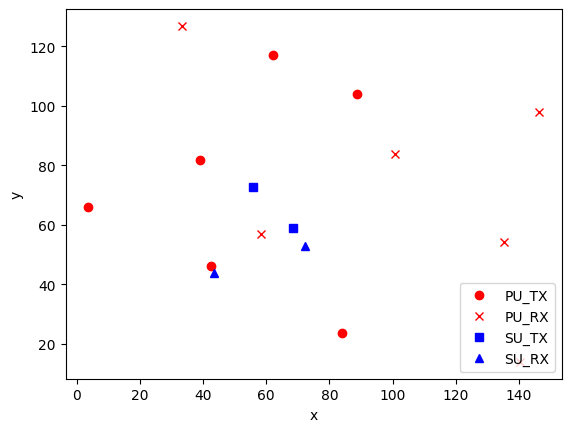

In [146]:

random_seed = 3
np.random.seed(random_seed)

# Initialize the environment
n_channel = 6
n_su = 2

env = DSA_Markov(n_channel, n_su)
env_copy = copy.deepcopy(env)

# Training parameters
if n_channel == 6:
    batch_size = 2000
elif n_channel == 22:
    batch_size = 4000
else:
    batch_size = 2000

replace_target_iter = 1
total_episode = batch_size * replace_target_iter * 100
epsilon_update_period = batch_size * replace_target_iter * 20
e_greedy = [0.3, 0.9, 1.0]
learning_rate = 0.01

flag_DQN_RC = True
flag_Myopic = True
flag_OnlineActorCritic = True
flag_OnlineActorCriticSNN = False
flag_OnlineActorCriticSNNPop = True


In [147]:

# ============================================================
# DQN_RC
# ============================================================
if flag_DQN_RC:
    env = copy.deepcopy(env_copy)

    DQN_RC_list = []
    epsilon_index = np.zeros(n_su, dtype=int)

    for k in range(n_su):
        DQN_tmp = DeepQNetwork(
            env.n_actions,
            env.n_features,
            reward_decay=0.9,
            e_greedy=e_greedy[0],
            replace_target_iter=replace_target_iter,
            memory_size=batch_size,
            lr=learning_rate
        )
        DQN_RC_list.append(DQN_tmp)

    observation = env.sense()

    reward_sum = np.zeros(n_su)
    overall_reward_1 = []
    success_hist_1 = []
    fail_PU_hist_1 = []
    fail_collision_hist_1 = []

    success_sum = 0
    fail_PU_sum = 0
    fail_collision_sum = 0

    action = np.zeros(n_su, dtype=np.int32)

    for step in range(total_episode):
        for k in range(n_su):
            action[k] = DQN_RC_list[k].choose_action(observation[k, :])

        env.render()
        env.render_SINR()

        reward = env.access(action)

        reward_sum += reward
        success_sum += env.success
        fail_PU_sum += env.fail_PU
        fail_collision_sum += env.fail_collision

        observation_ = env.sense()

        for k in range(n_su):
            DQN_RC_list[k].store_transition(
                observation[k, :],
                action[k],
                reward[k],
                observation_[k, :]
            )

        if ((step + 1) % batch_size == 0):
            for k in range(n_su):
                DQN_RC_list[k].learn()

            overall_reward_1.append(np.sum(reward_sum) / batch_size / n_su)
            success_hist_1.append(success_sum / n_su)
            fail_PU_hist_1.append(fail_PU_sum / n_su)
            fail_collision_hist_1.append(fail_collision_sum / n_su)

            reward_sum = np.zeros(n_su)
            success_sum = 0
            fail_PU_sum = 0
            fail_collision_sum = 0

        if ((step + 1) % epsilon_update_period == 0):
            for k in range(n_su):
                epsilon_index[k] = min(len(e_greedy) - 1, epsilon_index[k] + 1)
                DQN_RC_list[k].epsilon = e_greedy[epsilon_index[k]]
            print('DQN_RC epsilon update to %.1f' % DQN_RC_list[-1].epsilon)

        if ((step + 1) % (batch_size * replace_target_iter) == 0):
            print('DQN_RC Training time = %d;  success = %d;  fail_PU = %d;  fail_collision = %d' %
                    ((step + 1), success_hist_1[-1], fail_PU_hist_1[-1], fail_collision_hist_1[-1]))
            print('overall_reward_1 = %.4f' % overall_reward_1[-1])

        observation = observation_


DQN_RC Training time = 2000;  success = 1263;  fail_PU = 263;  fail_collision = 235
overall_reward_1 = 3.7275
DQN_RC Training time = 4000;  success = 1206;  fail_PU = 267;  fail_collision = 280
overall_reward_1 = 3.5316
DQN_RC Training time = 6000;  success = 1290;  fail_PU = 279;  fail_collision = 251
overall_reward_1 = 3.7869
DQN_RC Training time = 8000;  success = 1289;  fail_PU = 263;  fail_collision = 273
overall_reward_1 = 3.7734
DQN_RC Training time = 10000;  success = 1265;  fail_PU = 267;  fail_collision = 281
overall_reward_1 = 3.7197
DQN_RC Training time = 12000;  success = 1313;  fail_PU = 289;  fail_collision = 240
overall_reward_1 = 3.8487
DQN_RC Training time = 14000;  success = 1295;  fail_PU = 259;  fail_collision = 293
overall_reward_1 = 3.8042
DQN_RC Training time = 16000;  success = 1293;  fail_PU = 269;  fail_collision = 265
overall_reward_1 = 3.7917
DQN_RC Training time = 18000;  success = 1318;  fail_PU = 250;  fail_collision = 255
overall_reward_1 = 3.9058
DQN_R

In [148]:

# ============================================================
# Myopic
# ============================================================
if flag_Myopic:
    env = copy.deepcopy(env_copy)

    observation = env.sense()

    reward_sum = np.zeros(n_su)
    overall_reward_2 = []
    success_hist_2 = []
    fail_PU_hist_2 = []
    fail_collision_hist_2 = []

    success_sum = 0
    fail_PU_sum = 0
    fail_collision_sum = 0

    action = np.zeros(n_su, dtype=np.int32)

    for step in range(total_episode):
        for k in range(n_su):
            PU_prob = observation[k, :] * (1 - env.sense_error_prob[k, :]) + \
                        (1 - observation[k, :]) * env.sense_error_prob[k, :]

            expected_reward = (
                PU_prob * (env.goodToBad_prob * env.punish_interfer_PU)
                + PU_prob * (env.stayGood_prob * np.log2(1 + env.SINR[k, :]))
                + (1 - PU_prob) * (env.stayBad_prob * env.punish_interfer_PU)
                + (1 - PU_prob) * (env.badToGood_prob * np.log2(1 + env.SINR[k, :]))
            )

            if np.amax(expected_reward) > 0:
                action[k] = np.argmax(expected_reward)
            else:
                action[k] = env.n_channel

        env.render()
        env.render_SINR()

        reward = env.access(action)

        reward_sum += reward
        success_sum += env.success
        fail_PU_sum += env.fail_PU
        fail_collision_sum += env.fail_collision

        observation_ = env.sense()

        if ((step + 1) % batch_size == 0):
            overall_reward_2.append(np.sum(reward_sum) / batch_size / n_su)
            success_hist_2.append(success_sum / n_su)
            fail_PU_hist_2.append(fail_PU_sum / n_su)
            fail_collision_hist_2.append(fail_collision_sum / n_su)

            reward_sum = np.zeros(n_su)
            success_sum = 0
            fail_PU_sum = 0
            fail_collision_sum = 0

            if ((step + 1) % (batch_size * replace_target_iter) == 0):
                print('Myopic Training time = %d;  success = %d;  fail_PU = %d;  fail_collision = %d' %
                        ((step + 1), success_hist_2[-1], fail_PU_hist_2[-1], fail_collision_hist_2[-1]))
                print('overall_reward_2 = %.4f' % overall_reward_2[-1])

        observation = observation_


Myopic Training time = 2000;  success = 1008;  fail_PU = 90;  fail_collision = 939
overall_reward_2 = 3.1337
Myopic Training time = 4000;  success = 980;  fail_PU = 89;  fail_collision = 958
overall_reward_2 = 3.0332
Myopic Training time = 6000;  success = 997;  fail_PU = 100;  fail_collision = 947
overall_reward_2 = 3.0560
Myopic Training time = 8000;  success = 979;  fail_PU = 89;  fail_collision = 964
overall_reward_2 = 3.0154
Myopic Training time = 10000;  success = 1002;  fail_PU = 84;  fail_collision = 941
overall_reward_2 = 3.0832
Myopic Training time = 12000;  success = 1011;  fail_PU = 90;  fail_collision = 934
overall_reward_2 = 3.1148
Myopic Training time = 14000;  success = 985;  fail_PU = 91;  fail_collision = 948
overall_reward_2 = 3.0317
Myopic Training time = 16000;  success = 1023;  fail_PU = 87;  fail_collision = 920
overall_reward_2 = 3.1498
Myopic Training time = 18000;  success = 1021;  fail_PU = 80;  fail_collision = 932
overall_reward_2 = 3.1510
Myopic Training t

In [149]:

# ============================================================
# Online Actor Critic
# ============================================================
if flag_OnlineActorCritic:
    env = copy.deepcopy(env_copy)

    AC_list = []
    epsilon_index = np.zeros(n_su, dtype=int)

    for k in range(n_su):
        AC_tmp = OnlineActorCritic(
            env.n_actions,
            env.n_features,
            learning_rate=learning_rate,
            reward_decay=0.9,
            e_greedy=e_greedy[0],
            seed=random_seed + k
        )
        AC_list.append(AC_tmp)

    observation = env.sense()

    reward_sum = np.zeros(n_su)
    overall_reward_6 = []
    success_hist_6 = []
    fail_PU_hist_6 = []
    fail_collision_hist_6 = []

    success_sum = 0
    fail_PU_sum = 0
    fail_collision_sum = 0

    action = np.zeros(n_su, dtype=np.int32)

    for step in range(total_episode):
        for k in range(n_su):
            action[k] = AC_list[k].choose_action(observation[k, :])

        env.render()
        env.render_SINR()

        reward = env.access(action)

        reward_sum += reward
        success_sum += env.success
        fail_PU_sum += env.fail_PU
        fail_collision_sum += env.fail_collision

        observation_ = env.sense()

        for k in range(n_su):
            AC_list[k].learn(
                observation[k, :],
                action[k],
                reward[k],
                observation_[k, :]
            )

        if ((step + 1) % batch_size == 0):
            overall_reward_6.append(np.sum(reward_sum) / batch_size / n_su)
            success_hist_6.append(success_sum / n_su)
            fail_PU_hist_6.append(fail_PU_sum / n_su)
            fail_collision_hist_6.append(fail_collision_sum / n_su)

            reward_sum = np.zeros(n_su)
            success_sum = 0
            fail_PU_sum = 0
            fail_collision_sum = 0

        if ((step + 1) % epsilon_update_period == 0):
            for k in range(n_su):
                epsilon_index[k] = min(len(e_greedy) - 1, epsilon_index[k] + 1)
                AC_list[k].epsilon = e_greedy[epsilon_index[k]]
            print('OnlineActorCritic epsilon update to %.1f' % AC_list[-1].epsilon)

        if ((step + 1) % (batch_size * replace_target_iter) == 0):
            print('OnlineActorCritic Training time = %d;  success = %d;  fail_PU = %d;  fail_collision = %d' %
                    ((step + 1), success_hist_6[-1], fail_PU_hist_6[-1], fail_collision_hist_6[-1]))
            print('overall_reward_6 = %.4f' % overall_reward_6[-1])

        observation = observation_


OnlineActorCritic Training time = 2000;  success = 1396;  fail_PU = 219;  fail_collision = 209
overall_reward_6 = 4.1775
OnlineActorCritic Training time = 4000;  success = 1372;  fail_PU = 208;  fail_collision = 251
overall_reward_6 = 4.1027
OnlineActorCritic Training time = 6000;  success = 1373;  fail_PU = 204;  fail_collision = 237
overall_reward_6 = 4.1028
OnlineActorCritic Training time = 8000;  success = 1368;  fail_PU = 202;  fail_collision = 247
overall_reward_6 = 4.0990
OnlineActorCritic Training time = 10000;  success = 1372;  fail_PU = 200;  fail_collision = 258
overall_reward_6 = 4.1162
OnlineActorCritic Training time = 12000;  success = 1365;  fail_PU = 195;  fail_collision = 274
overall_reward_6 = 4.0939
OnlineActorCritic Training time = 14000;  success = 1378;  fail_PU = 211;  fail_collision = 230
overall_reward_6 = 4.1296
OnlineActorCritic Training time = 16000;  success = 1400;  fail_PU = 199;  fail_collision = 242
overall_reward_6 = 4.2024
OnlineActorCritic Training t

In [150]:

# ============================================================
# Online Actor Critic SNN
# ============================================================
if flag_OnlineActorCriticSNN:
    env = copy.deepcopy(env_copy)

    AC_SNN_list = []
    epsilon_index = np.zeros(n_su, dtype=int)

    for k in range(n_su):
        AC_tmp = OnlineActorCriticSNN(
            env.n_actions,
            env.n_features,
            learning_rate=0.001,
            reward_decay=0.9,
            e_greedy=e_greedy[0],
            hidden_size=32,
            spike_window=50,
            mem_decay=0.9,
            threshold=0.5,
            input_scale=1.0,
            value_scale=5.0,
            seed=random_seed + 100 + k
        )
        AC_SNN_list.append(AC_tmp)

    observation = env.sense()

    reward_sum = np.zeros(n_su)
    overall_reward_7 = []
    success_hist_7 = []
    fail_PU_hist_7 = []
    fail_collision_hist_7 = []

    success_sum = 0
    fail_PU_sum = 0
    fail_collision_sum = 0

    action = np.zeros(n_su, dtype=np.int32)

    for step in range(total_episode):
        for k in range(n_su):
            action[k] = AC_SNN_list[k].choose_action(observation[k, :])

        env.render()
        env.render_SINR()

        reward = env.access(action)

        reward_sum += reward
        success_sum += env.success
        fail_PU_sum += env.fail_PU
        fail_collision_sum += env.fail_collision

        observation_ = env.sense()

        for k in range(n_su):
            AC_SNN_list[k].learn(
                observation[k, :],
                action[k],
                reward[k],
                observation_[k, :]
            )

        if ((step + 1) % batch_size == 0):
            overall_reward_7.append(np.sum(reward_sum) / batch_size / n_su)
            success_hist_7.append(success_sum / n_su)
            fail_PU_hist_7.append(fail_PU_sum / n_su)
            fail_collision_hist_7.append(fail_collision_sum / n_su)

            reward_sum = np.zeros(n_su)
            success_sum = 0
            fail_PU_sum = 0
            fail_collision_sum = 0

        if ((step + 1) % epsilon_update_period == 0):
            for k in range(n_su):
                epsilon_index[k] = min(len(e_greedy) - 1, epsilon_index[k] + 1)
                AC_SNN_list[k].epsilon = e_greedy[epsilon_index[k]]
            print('OnlineActorCriticSNN epsilon update to %.1f' % AC_SNN_list[-1].epsilon)

        if ((step + 1) % (batch_size * replace_target_iter) == 0):
            print('OnlineActorCriticSNN Training time = %d;  success = %d;  fail_PU = %d;  fail_collision = %d' %
                    ((step + 1), success_hist_7[-1], fail_PU_hist_7[-1], fail_collision_hist_7[-1]))
            print('overall_reward_7 = %.4f' % overall_reward_7[-1])

        observation = observation_


In [151]:

# ============================================================
# Online Actor Critic SNN Population-Coded
# ============================================================
if flag_OnlineActorCriticSNNPop:
    env = copy.deepcopy(env_copy)

    AC_SNN_POP_list = []
    epsilon_index = np.zeros(n_su, dtype=int)

    for k in range(n_su):
        AC_tmp = OnlineActorCriticSNNPop(
            env.n_actions,
            env.n_features,
            learning_rate=0.01,
            reward_decay=0.9,
            e_greedy=e_greedy[0],
            hidden_size=32,
            actor_pop_size=4,
            critic_pop_size=8,
            spike_window=50,
            mem_decay=0.9,
            threshold=0.5,
            input_scale=1.0,
            value_scale=5.0,
            seed=random_seed + 200 + k
        )
        AC_SNN_POP_list.append(AC_tmp)

    observation = env.sense()

    reward_sum = np.zeros(n_su)
    overall_reward_8 = []
    success_hist_8 = []
    fail_PU_hist_8 = []
    fail_collision_hist_8 = []

    success_sum = 0
    fail_PU_sum = 0
    fail_collision_sum = 0

    action = np.zeros(n_su, dtype=np.int32)

    for step in range(total_episode):
        for k in range(n_su):
            action[k] = AC_SNN_POP_list[k].choose_action(observation[k, :])

        env.render()
        env.render_SINR()

        reward = env.access(action)

        reward_sum += reward
        success_sum += env.success
        fail_PU_sum += env.fail_PU
        fail_collision_sum += env.fail_collision

        observation_ = env.sense()

        for k in range(n_su):
            AC_SNN_POP_list[k].learn(
                observation[k, :],
                action[k],
                reward[k],
                observation_[k, :]
            )

        if ((step + 1) % batch_size == 0):
            overall_reward_8.append(np.sum(reward_sum) / batch_size / n_su)
            success_hist_8.append(success_sum / n_su)
            fail_PU_hist_8.append(fail_PU_sum / n_su)
            fail_collision_hist_8.append(fail_collision_sum / n_su)

            reward_sum = np.zeros(n_su)
            success_sum = 0
            fail_PU_sum = 0
            fail_collision_sum = 0

        if ((step + 1) % epsilon_update_period == 0):
            for k in range(n_su):
                epsilon_index[k] = min(len(e_greedy) - 1, epsilon_index[k] + 1)
                AC_SNN_POP_list[k].epsilon = e_greedy[epsilon_index[k]]
            print('OnlineActorCriticSNNPop epsilon update to %.1f' % AC_SNN_POP_list[-1].epsilon)

        if ((step + 1) % (batch_size * replace_target_iter) == 0):
            print('OnlineActorCriticSNNPop Training time = %d;  success = %d;  fail_PU = %d;  fail_collision = %d' %
                    ((step + 1), success_hist_8[-1], fail_PU_hist_8[-1], fail_collision_hist_8[-1]))
            print('overall_reward_8 = %.4f' % overall_reward_8[-1])

        observation = observation_


OnlineActorCriticSNNPop Training time = 2000;  success = 1250;  fail_PU = 271;  fail_collision = 253
overall_reward_8 = 3.6557
OnlineActorCriticSNNPop Training time = 4000;  success = 1255;  fail_PU = 251;  fail_collision = 249
overall_reward_8 = 3.6845
OnlineActorCriticSNNPop Training time = 6000;  success = 1255;  fail_PU = 258;  fail_collision = 255
overall_reward_8 = 3.6912
OnlineActorCriticSNNPop Training time = 8000;  success = 1257;  fail_PU = 257;  fail_collision = 253
overall_reward_8 = 3.7141
OnlineActorCriticSNNPop Training time = 10000;  success = 1234;  fail_PU = 285;  fail_collision = 265
overall_reward_8 = 3.6000
OnlineActorCriticSNNPop Training time = 12000;  success = 1261;  fail_PU = 271;  fail_collision = 237
overall_reward_8 = 3.6956
OnlineActorCriticSNNPop Training time = 14000;  success = 1241;  fail_PU = 256;  fail_collision = 266
overall_reward_8 = 3.6461
OnlineActorCriticSNNPop Training time = 16000;  success = 1249;  fail_PU = 244;  fail_collision = 266
overal

In [152]:

# ============================================================
# Save results
# ============================================================
file_folder = '.\\result\\channel_%d_su_%d_punish_-2' % (n_channel, n_su)
os.makedirs(file_folder, exist_ok=True)

np.save(file_folder + '\\PU_TX_x', env.PU_TX_x)
np.save(file_folder + '\\PU_TX_y', env.PU_TX_y)
np.save(file_folder + '\\PU_RX_x', env.PU_RX_x)
np.save(file_folder + '\\PU_RX_y', env.PU_RX_y)
np.save(file_folder + '\\SU_TX_x', env.SU_TX_x)
np.save(file_folder + '\\SU_TX_y', env.SU_TX_y)
np.save(file_folder + '\\SU_RX_x', env.SU_RX_x)
np.save(file_folder + '\\SU_RX_y', env.SU_RX_y)

if flag_DQN_RC:
    np.save(file_folder + '\\success_hist_1', success_hist_1)
    np.save(file_folder + '\\fail_PU_hist_1', fail_PU_hist_1)
    np.save(file_folder + '\\fail_collision_hist_1', fail_collision_hist_1)
    np.save(file_folder + '\\overall_reward_1', overall_reward_1)

if flag_Myopic:
    np.save(file_folder + '\\success_hist_2', success_hist_2)
    np.save(file_folder + '\\fail_PU_hist_2', fail_PU_hist_2)
    np.save(file_folder + '\\fail_collision_hist_2', fail_collision_hist_2)
    np.save(file_folder + '\\overall_reward_2', overall_reward_2)

if flag_OnlineActorCritic:
    np.save(file_folder + '\\success_hist_6', success_hist_6)
    np.save(file_folder + '\\fail_PU_hist_6', fail_PU_hist_6)
    np.save(file_folder + '\\fail_collision_hist_6', fail_collision_hist_6)
    np.save(file_folder + '\\overall_reward_6', overall_reward_6)

if flag_OnlineActorCriticSNN:
    np.save(file_folder + '\\success_hist_7', success_hist_7)
    np.save(file_folder + '\\fail_PU_hist_7', fail_PU_hist_7)
    np.save(file_folder + '\\fail_collision_hist_7', fail_collision_hist_7)
    np.save(file_folder + '\\overall_reward_7', overall_reward_7)
if flag_OnlineActorCriticSNNPop:
    np.save(file_folder + '\\success_hist_8', success_hist_8)
    np.save(file_folder + '\\fail_PU_hist_8', fail_PU_hist_8)
    np.save(file_folder + '\\fail_collision_hist_8', fail_collision_hist_8)
    np.save(file_folder + '\\overall_reward_8', overall_reward_8)


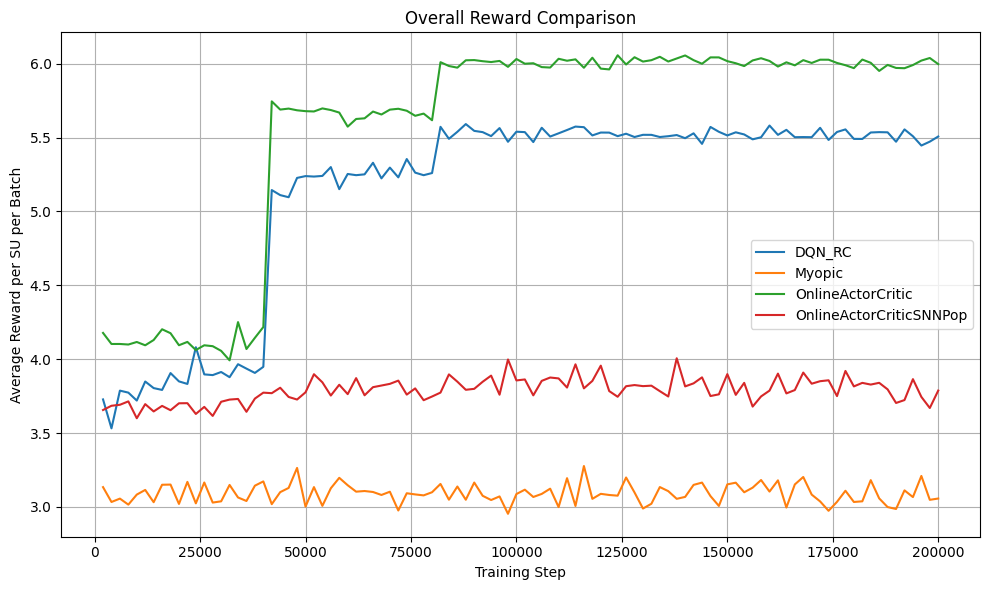

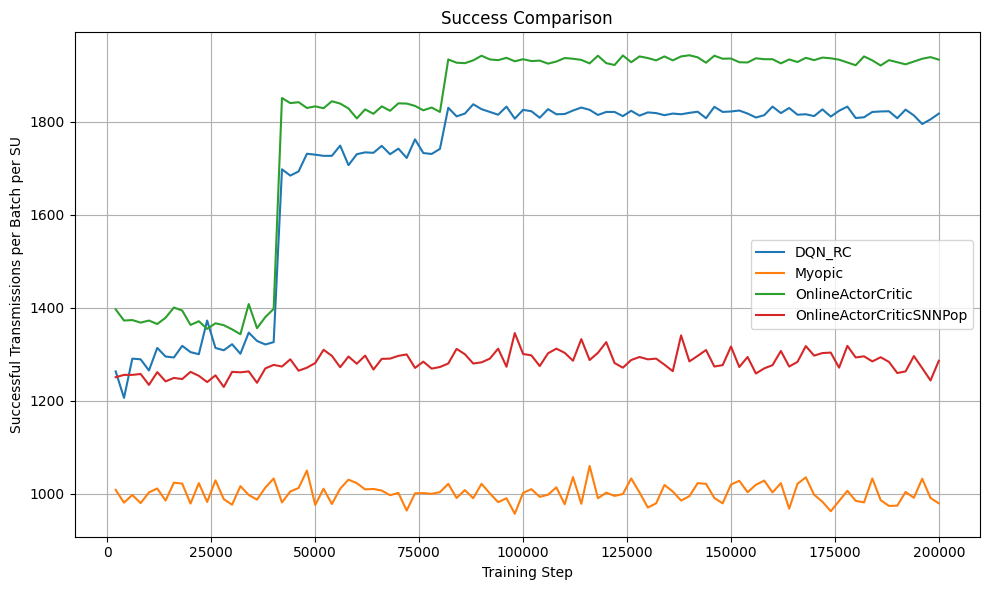

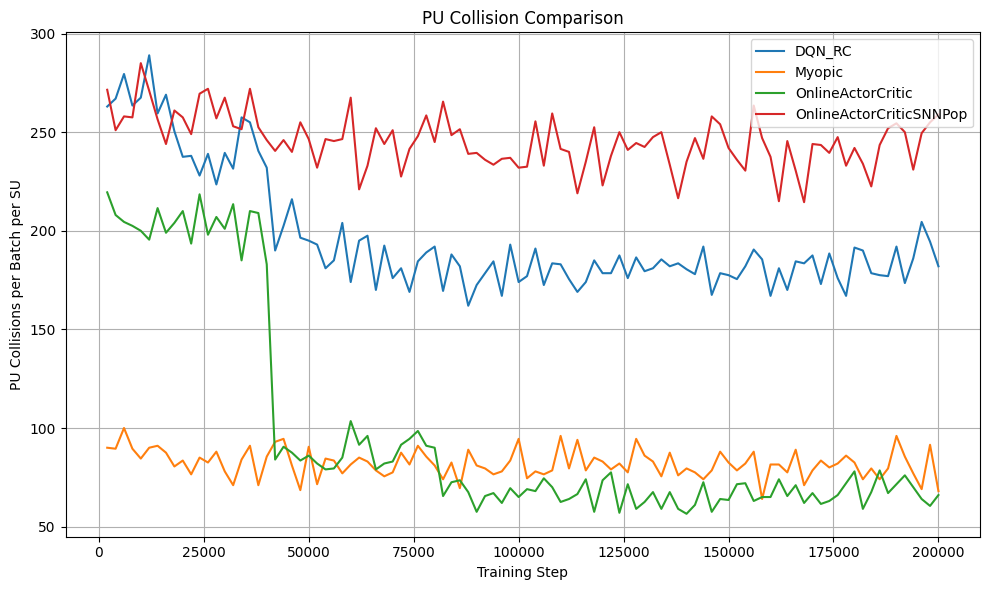

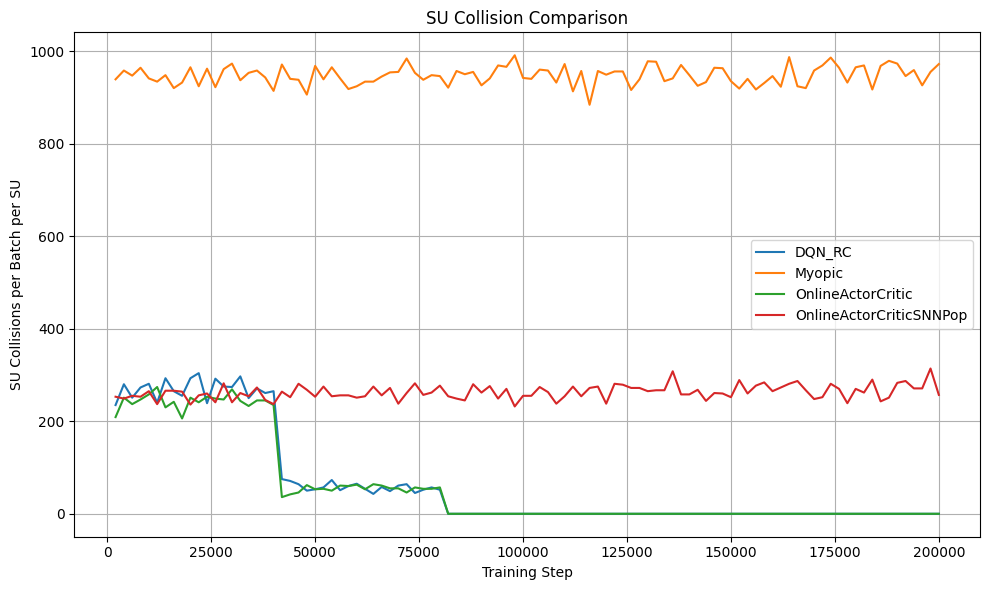

In [153]:

# ============================================================
# Plot results
# ============================================================
labels = [
    'DQN_RC',
    'Myopic',
    'OnlineActorCritic',
    'OnlineActorCriticSNN',
    'OnlineActorCriticSNNPop'
]

plot_metric(
    [
        overall_reward_1 if flag_DQN_RC else None,
        overall_reward_2 if flag_Myopic else None,
        overall_reward_6 if flag_OnlineActorCritic else None,
        overall_reward_7 if flag_OnlineActorCriticSNN else None,
        overall_reward_8 if flag_OnlineActorCriticSNNPop else None,

    ],
    labels,
    'Overall Reward Comparison',
    'Average Reward per SU per Batch',
    batch_size
)

plot_metric(
    [
        success_hist_1 if flag_DQN_RC else None,
        success_hist_2 if flag_Myopic else None,
        success_hist_6 if flag_OnlineActorCritic else None,
        success_hist_7 if flag_OnlineActorCriticSNN else None,
        success_hist_8 if flag_OnlineActorCriticSNNPop else None,
    ],
    labels,
    'Success Comparison',
    'Successful Transmissions per Batch per SU',
    batch_size
)

plot_metric(
    [
        fail_PU_hist_1 if flag_DQN_RC else None,
        fail_PU_hist_2 if flag_Myopic else None,
        fail_PU_hist_6 if flag_OnlineActorCritic else None,
        fail_PU_hist_7 if flag_OnlineActorCriticSNN else None,
        fail_PU_hist_8 if flag_OnlineActorCriticSNNPop else None,
    ],
    labels,
    'PU Collision Comparison',
    'PU Collisions per Batch per SU',
    batch_size
)

plot_metric(
    [
        fail_collision_hist_1 if flag_DQN_RC else None,
        fail_collision_hist_2 if flag_Myopic else None,
        fail_collision_hist_6 if flag_OnlineActorCritic else None,
        fail_collision_hist_7 if flag_OnlineActorCriticSNN else None,
        fail_collision_hist_8 if flag_OnlineActorCriticSNNPop else None,

    ],
    labels,
    'SU Collision Comparison',
    'SU Collisions per Batch per SU',
    batch_size
)